In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
df1 = pd.read_excel('/kaggle/input/mot-questionnaire/questionnaire(1-200).xlsx')
df2 = pd.read_excel('/kaggle/input/mot-questionnaire/questionnaire(201-322).xlsx')
df = pd.concat([df1, df2], ignore_index=True)

In [3]:
df

,ID,Start time,Completion time,Email,Name,Last modified time,ID do participante,Cubo da Matéria (Cubo 1):\n\nNADA MUITO,Cubo da Vida (Cubo 2):\n\nNADA MUITO,Cubo do Pensamento (Cubo 3): \n\nNADA MUITO,...,Gostaria de visitar o museu de novo no futuro?,Você recomendaria o museu a seus amigos e familiares?\n,Faixa etária,Gênero \n,Qual grupo racial você se identifica? \n(As opções abaixo reproduzem as utilizadas pelo IBGE no Censo e nas demais pesquisas oficiais sobre a população brasileira)\n,Você possui alguma deficiência?,Qual deficiência você possui?,Você tem filhos? \n,Onde você mora?\n,"Deseja compartilhar algo mais sobre sua visita ou sua experiência de hoje? \nLeremos com muito cuidado e, novamente, tudo será anônimo.\n"
0,12,2023-09-25 21:54:11,2023-09-25 22:07:35,anonymous,NaN,NaN,D05.p009,NaN,NaN,NaN,...,Não,Não,31-59 anos,Masculino,Outro,NaN,NaN,Não,Cidade do Rio,NaN
1,14,2023-09-26 16:11:42,2023-09-26 16:16:28,anonymous,NaN,NaN,D05_p001,4.0,4.0,3.0,...,Sim,Sim,19-30 anos,Feminino,Amarelo,Sim,Outra,Não,Cidade do Rio,NaN
2,15,2023-09-26 16:34:00,2023-09-26 16:57:43,anonymous,NaN,NaN,D03_p011,8.0,3.0,6.0,...,Sim,Sim,31-59 anos,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,NaN
3,16,2023-09-26 16:33:48,2023-09-26 16:59:12,anonymous,NaN,NaN,D03_p0010,8.0,4.0,8.0,...,Sim,Sim,31-59 anos,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,Foi uma das experiencias mais incriveis que ja...
4,17,2023-09-26 16:59:30,2023-09-26 17:19:56,anonymous,NaN,NaN,D03_p012,7.0,7.0,7.0,...,Sim,Sim,19-30 anos,Feminino,Pardo,Não,NaN,Não,Cidade do Rio,Adorei a esperiencia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,118,2023-10-01 23:17:45,2023-10-02 00:00:33,anonymous,NaN,NaN,D05-P050,5.0,5.0,8.0,...,Talvez,Sim,19-30 anos,Feminino,Branco,Não,NaN,Não,Outro Estado do Brasil,NaN
318,119,2023-10-01 23:42:19,2023-10-02 00:01:30,anonymous,NaN,NaN,R40,5.0,4.0,4.0,...,Talvez,Sim,31-59 anos,Masculino,Branco,Não,NaN,Não,Cidade do Rio,NaN
319,120,2023-10-01 23:44:36,2023-10-02 00:08:06,anonymous,NaN,NaN,D01-P064,8.0,8.0,8.0,...,Sim,Sim,19-30 anos,Masculino,Branco,Não,NaN,Sim,Outro Estado do Brasil,NaN
320,121,2023-10-02 00:01:35,2023-10-02 00:08:15,anonymous,NaN,NaN,R41,8.0,8.0,8.0,...,Sim,Sim,19-30 anos,Feminino,Pardo,Não,NaN,Não,Outro Estado do Brasil,NaN


In [4]:
gender = df.iloc[:, 43]
race = df.iloc[:, 44]
location_of_orogin = df.iloc[:, 48]

# Gender Distribution Comparison

In [5]:
unique_gender_values = gender.unique()
for value in unique_gender_values:
    print(value)

Masculino
Feminino
Não sei / Prefiro não responder
Não-binárie


In [6]:
# word_mapping = {
#     'Masculino': 'Male',
#     'Feminino': 'Female',
#     'Não-binárie': 'Non-binary',
#     'Não sei / Prefiro não responder': "I don't know / I prefer not to answer"
# }

# gender = gender.replace(word_mapping)

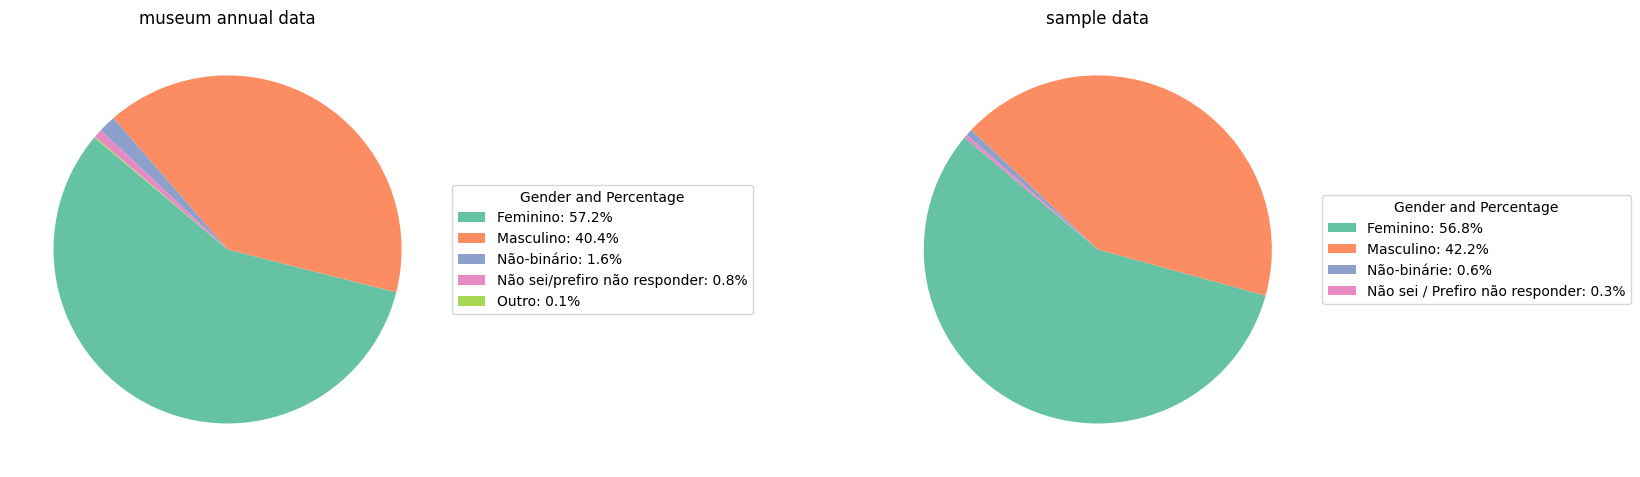

In [39]:
# MUSEUM DATA
data1 = {
    'Gender': ['Feminino', 'Masculino', 'Não-binário', 'Não sei/prefiro não responder', 'Outro'],
    'Percentage': [57.2, 40.4, 1.6, 0.8, 0.1]
}
# Use Seaborn's "Set2" color palette
sns.set_palette("Set2")

# Dictionary mapping race categories to colors
color_mapping = {
    'Branco': sns.color_palette()[0],
    'Preto': sns.color_palette()[1],
    'Pardo': sns.color_palette()[2],
    'Indígena': sns.color_palette()[3],
    'Amarelo': sns.color_palette()[4],
    'Não sei / Prefiro não responder': sns.color_palette()[5],
    'Outro': sns.color_palette()[6]
}
# SAMPLE DATA
gender_counts = gender.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

p1, _ = axes[0].pie(data1['Percentage'], startangle=140)
axes[0].set_title('museum annual data') 

legend_labels_data1 = [f'{label}: {percentage:.1f}%' for label, percentage in zip(data1['Gender'], data1['Percentage'])]
axes[0].legend(legend_labels_data1, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Gender and Percentage')

p2, _ = axes[1].pie(gender_counts, labels=None, startangle=140)
axes[1].set_title('sample data')

legend_labels_data2 = [f'{label}: {percentage:.1f}%' for label, percentage in zip(gender_counts.index, gender_counts / gender_counts.sum() * 100)]
axes[1].legend(legend_labels_data2, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Gender and Percentage')

plt.tight_layout()
fig.subplots_adjust(wspace=1)


plt.savefig('gender.png', dpi=300, bbox_inches='tight')

plt.show()


# Race Distribution Comparison

In [8]:
unique_race_values = race.unique()
for value in unique_race_values:
    print(value)

Outro
Amarelo
Pardo
Branco
Preto
Indígena
Não sei / Prefiro não responder


In [9]:
# word_mapping = {
#     'Branco': 'White',
#     'Pardo': 'Brown',
#     'Preto': 'Black',
#     'Amarelo': 'Yellow',
#     'Amarelo': 'Other',
#     'Indígena': 'Indigenous',
#     'Não sei / Prefiro não responder': "I don't know / I prefer not to answer"
# }

# race = race.replace(word_mapping)

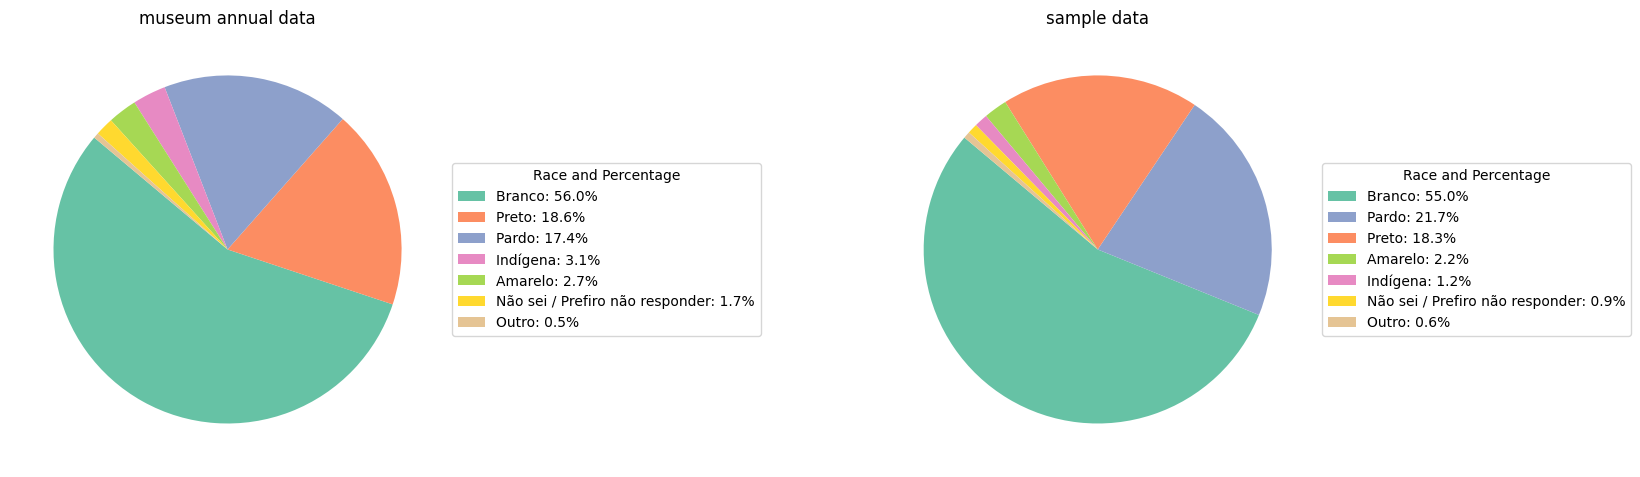

In [40]:
# MUSEUM DATA
data1 = {
    'Race': ['Branco', 'Preto', 'Pardo', 'Indígena','Amarelo' , 'Não sei / Prefiro não responder', 'Outro'],
    'Percentage': [56, 18.6, 17.4, 3.1, 2.7, 1.7, 0.5]
}

# Use Seaborn's "Set2" color palette
sns.set_palette("Set2")

# Dictionary mapping race categories to colors
color_mapping = {
    'Branco': sns.color_palette()[0],
    'Preto': sns.color_palette()[1],
    'Pardo': sns.color_palette()[2],
    'Indígena': sns.color_palette()[3],
    'Amarelo': sns.color_palette()[4],
    'Não sei / Prefiro não responder': sns.color_palette()[5],
    'Outro': sns.color_palette()[6]
}
# SAMPLE DATA
race_counts = race.value_counts()

# Create a list of colors based on the color mapping
colors_data1 = [color_mapping[race] for race in data1['Race']]
colors_data2 = [color_mapping[race] for race in race_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

p1, _ = axes[0].pie(data1['Percentage'], startangle=140, colors=colors_data1)
axes[0].set_title('museum annual data')

legend_labels_data1 = [f'{label}: {percentage:.1f}%' for label, percentage in zip(data1['Race'], data1['Percentage'])]
axes[0].legend(legend_labels_data1, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Race and Percentage')

p2, _ = axes[1].pie(race_counts, labels=None, startangle=140, colors=colors_data2)
axes[1].set_title('sample data')

legend_labels_data2 = [f'{label}: {percentage:.1f}%' for label, percentage in zip(race_counts.index, race_counts / race_counts.sum() * 100)]
axes[1].legend(legend_labels_data2, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Race and Percentage')

plt.tight_layout()
fig.subplots_adjust(wspace=1)

plt.savefig('race.png', dpi=300, bbox_inches='tight')

plt.show()

# Location of Origin Distribution Comparison

In [41]:
unique_location_values = location_of_orogin.unique()
for value in unique_location_values:
    print(value)

Cidade do Rio
Outro Estado do Brasil
Outro País
Estado do Rio


In [12]:
# word_mapping = {
#     'Cidade do Rio': 'City of Rio de Janeiro',
#     'Outro Estado do Brasil': 'Other Brazilian state',
#     'Outro País': 'Other country',
#     'Estado do Rio': 'State of Rio de Janeiro',
# }

# location_of_orogin = location_of_orogin.replace(word_mapping)

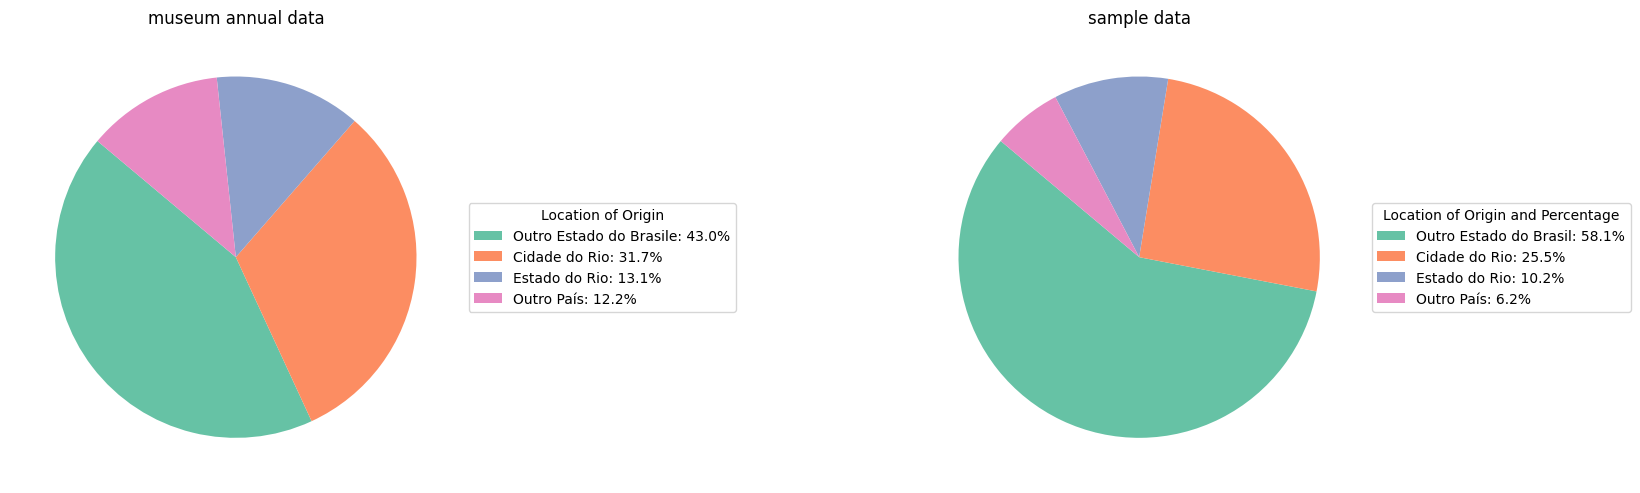

In [42]:
# MUSEUM DATA
data1 = {
    'Location of Origin': ['Outro Estado do Brasile', 'Cidade do Rio', 'Estado do Rio', 'Outro País'],
    'Percentage': [43, 31.7, 13.1, 12.2]
}


# SAMPLE DATA
location_counts = location_of_orogin.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

p1, _ = axes[0].pie(data1['Percentage'], startangle=140)
axes[0].set_title('museum annual data') 

legend_labels_data1 = [f'{label}: {percentage:.1f}%' for label, percentage in zip(data1['Location of Origin'], data1['Percentage'])]
axes[0].legend(legend_labels_data1, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Location of Origin')

p2, _ = axes[1].pie(location_counts, labels=None, startangle=140)
axes[1].set_title('sample data')

legend_labels_data2 = [f'{label}: {percentage:.1f}%' for label, percentage in zip(location_counts.index, location_counts / location_counts.sum() * 100)]
axes[1].legend(legend_labels_data2, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Location of Origin and Percentage')

plt.tight_layout()
fig.subplots_adjust(wspace=1)


plt.savefig('location.png', dpi=300, bbox_inches='tight')

plt.show()


In [14]:
# ////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

In [15]:
# these questions have been translated with google translate so these need to be revised
Columns_in_english = [ "ID",
"Start time",
"Completion time",
"Email",
"Name",
"Last modified time",
"Participant ID",
"Cube of Matter (Cube 1):",
"Cube of Life (Cube 2):",
"Thought Cube (Cube 3):",
"Cube of Matter 2(Cube 1):",
"Cube of Life 2(Cube 2):",
"Thought Cube 2(Cube 3):",
"Admiration",
"Confusion",
"Haunt",
"Disorientation",
"Amazement",
"Fascination",
"Amazing",
"Curiosity",
"Perplexity",
"I felt a closer sense of identity, of who I am.",
"I felt a psychological connection to everyone/everything around me.",
"I felt a physical connection to everyone/everything around me.",
"Everything seemed to be connected.",
"I experienced a feeling of confinement.",
"I experienced a feeling of oppression.",
"I experienced a feeling of tension.",
"My heart was racing.",
"It took my breath away.",
"I felt chills.",
"I felt physically smaller.",
"I felt trivial, in the grand scheme of things.",
"The world seemed vast.",
"What did you learn about during your visit?",
"Is this your first time visiting the Museum of Tomorrow?",
"If not, how many times have you visited us previously?",
"Did you watch the movie Cosmos, projected onto the sphere?",
"How many people accompanied you on this visit?",
"Would you like to visit the museum again in the future?",
"Would you recommend the museum to your friends and family?",
"Age group",
"Gender",
"Which racial group do you identify with?",
"Do you have any disabilities?",
"What disability do you have?",
"Do you have children? ",
"Where do you live?",
"Would you like to share something more about your visit or your experience today?"]

In [16]:
Columns_in_portuguese = ["ID",
"Start time",
"Completion time",
"Email",
"Name",
"Last modified time",
"ID do participante",
"Cubo da Matéria (Cubo 1)1:",
"Cubo da Vida (Cubo 2)1:",
"Cubo do Pensamento (Cubo 3)1:",
"Cubo da Matéria (Cubo 1)2:",
"Cubo da Vida (Cubo 2)2:",
"Cubo do Pensamento (Cubo 3)2:",
"Admiração",
"Confusão",
"Assombro",
"Desorientação",
"Maravilhamento",
"Fascinação",
"Pasmo",
"Curiosidade",
"Perplexidade",
"Senti um senso mais próximo de identidade, de quem eu sou.",
"Senti uma conexão psicológica a todos/tudo ao meu redor.",
"Senti uma conexão física a todos/tudo ao meu redor.",
"Tudo parecia estar conectado.",
"Experimentei uma sensação de confinamento.",
"Experimentei uma sensação de opressão.",
"Experimentei uma sensação de tensão.",
"Meu coração estava acelerado.",
"Fiquei sem fôlego.",
"Senti calafrios.",
"Me senti fisicamente menor.",
"Me senti trivial, no grande esquema das coisas.",
"O mundo parecia vasto.",
"Sobre o que você aprendeu durante sua visita?",
"É a primeira vez que você visita o Museu do Amanhã?",
"Se não, quantas vezes você nos visitou anteriormente?",
"Você assistiu ao filme Cosmos, projetado na esfera?",
"Quantas pessoas lhe acompanharam nesta visita? ",
"Gostaria de visitar o museu de novo no futuro?",
"Você recomendaria o museu a seus amigos e familiares?",
"Faixa etária",
"Gênero",
"Qual grupo racial você se identifica?",
"Você possui alguma deficiência?",
"Qual deficiência você possui?",
"Você tem filhos?",
"Onde você mora?",
"Deseja compartilhar algo mais sobre sua visita ou sua experiência de hoje?"]

In [17]:
df.columns = Columns_in_english

In [18]:
print(df.columns)

Index(['ID', 'Start time', 'Completion time', 'Email', 'Name',
       'Last modified time', 'Participant ID', 'Cube of Matter (Cube 1):',
       'Cube of Life (Cube 2):', 'Thought Cube (Cube 3):',
       'Cube of Matter 2(Cube 1):', 'Cube of Life 2(Cube 2):',
       'Thought Cube 2(Cube 3):', 'Admiration', 'Confusion', 'Haunt',
       'Disorientation', 'Amazement', 'Fascination', 'Amazing', 'Curiosity',
       'Perplexity', 'I felt a closer sense of identity, of who I am.',
       'I felt a psychological connection to everyone/everything around me.',
       'I felt a physical connection to everyone/everything around me.',
       'Everything seemed to be connected.',
       'I experienced a feeling of confinement.',
       'I experienced a feeling of oppression.',
       'I experienced a feeling of tension.', 'My heart was racing.',
       'It took my breath away.', 'I felt chills.',
       'I felt physically smaller.',
       'I felt trivial, in the grand scheme of things.',
       'Th

In [19]:
df['What did you learn about during your visit?']

0                       Sustentabilidade;Biodiversidade;
1                                      Sustentabilidade;
2                                 Diversidade Cultural ;
3      Biodiversidade;Diversidade Cultural ;Recursos ...
4      Sustentabilidade;Biodiversidade;Diversidade Cu...
                             ...                        
317    Diversidade Cultural ;Biodiversidade;Recursos ...
318                   Biodiversidade;Recursos Naturais ;
319                Biodiversidade;Diversidade Cultural ;
320    Diversidade Cultural ;Recursos Naturais ;Biodi...
321    Biodiversidade;Diversidade Cultural ;Sustentab...
Name: What did you learn about during your visit?, Length: 322, dtype: object

# How many people accompanied you on this visit? (Age Group)

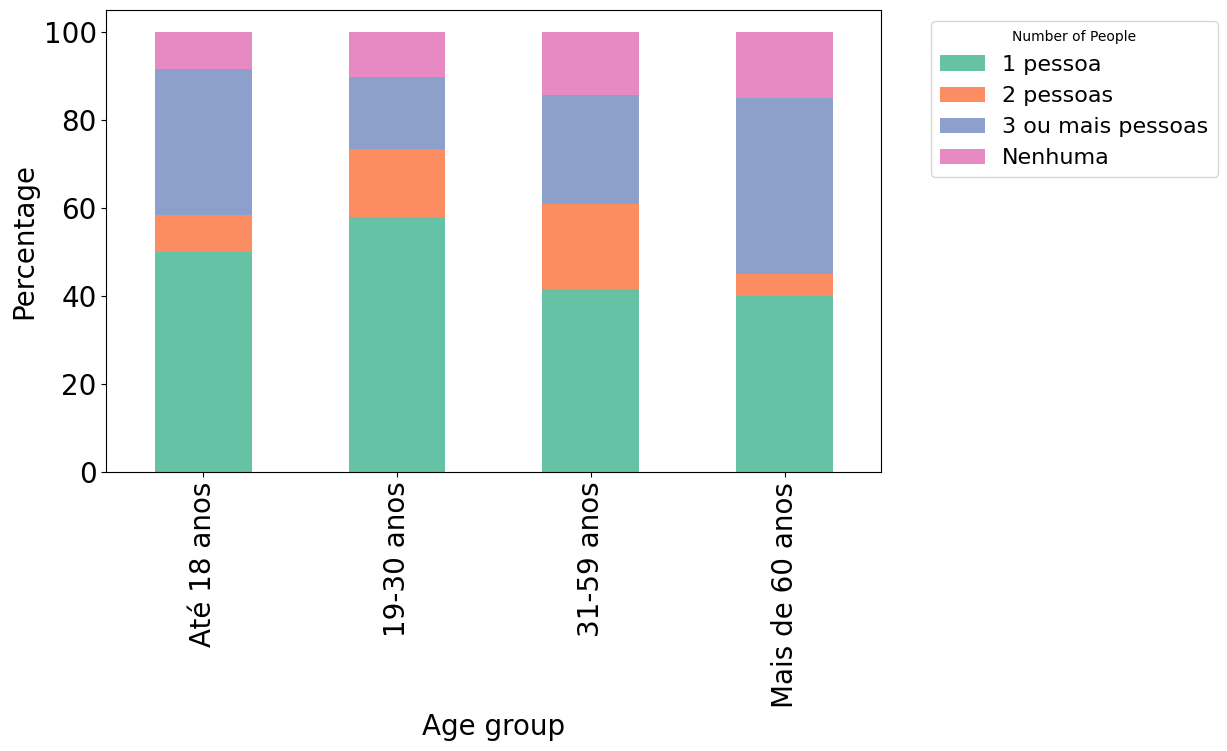

In [22]:
age_categories = ['Até 18 anos', '19-30 anos', '31-59 anos', 'Mais de 60 anos']

grouped_data = df.groupby(['Age group', 'How many people accompanied you on this visit?']).size().unstack().fillna(0)

grouped_data_percentage = grouped_data.div(grouped_data.sum(axis=1), axis=0) * 100

ax = grouped_data_percentage.plot(kind='bar', stacked=True, figsize=(10, 6), fontsize=20)

plt.xlabel('Age group', fontsize=20)
plt.ylabel('Percentage', fontsize=20)
plt.legend(title='Number of People', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

plt.savefig('accompany_percentage.png', dpi=300, bbox_inches='tight')

plt.show()

# How many people accompanied you on this visit? (Gender)

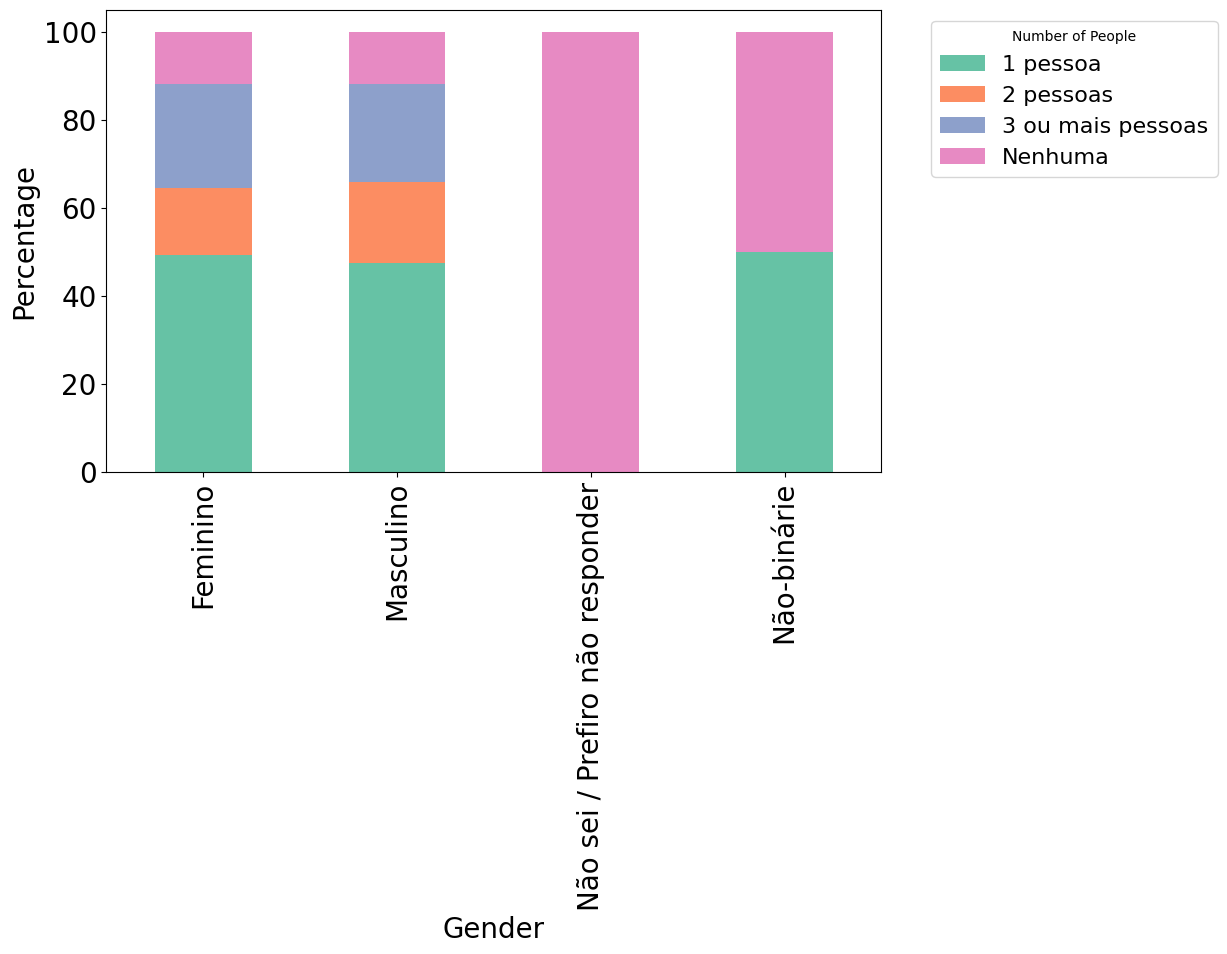

In [44]:
grouped_data = df.groupby(['Gender', 'How many people accompanied you on this visit?']).size().unstack().fillna(0)

grouped_data_percentage = grouped_data.div(grouped_data.sum(axis=1), axis=0) * 100

ax = grouped_data_percentage.plot(kind='bar', stacked=True, figsize=(10, 6), fontsize=20)

plt.xlabel('Gender', fontsize=20)
plt.ylabel('Percentage', fontsize=20)
plt.legend(title='Number of People', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

plt.savefig('accompany2.png', dpi=300, bbox_inches='tight')

plt.show()


**Since the sample size of two of the columns is too small, it is advisable to present them in a smaller secondary graph, with the primary focus of the graphs being the comparison between males and females.**

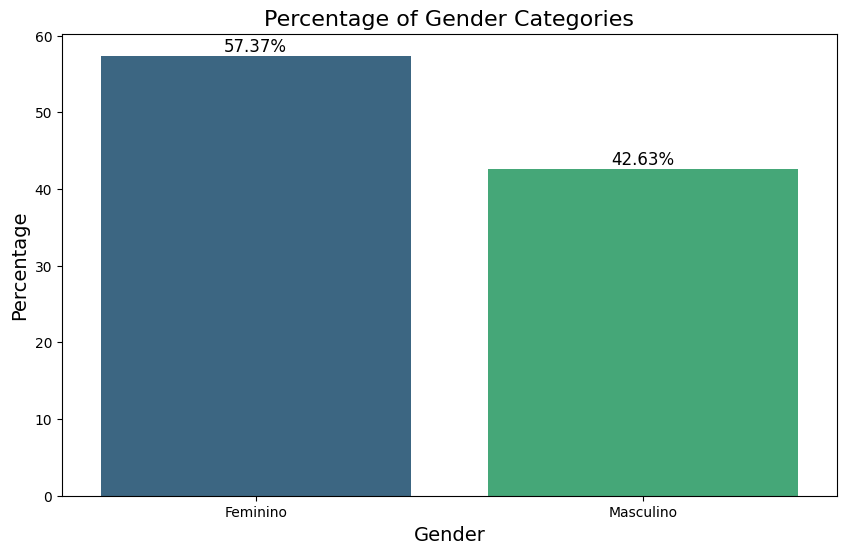

<Figure size 1000x600 with 0 Axes>

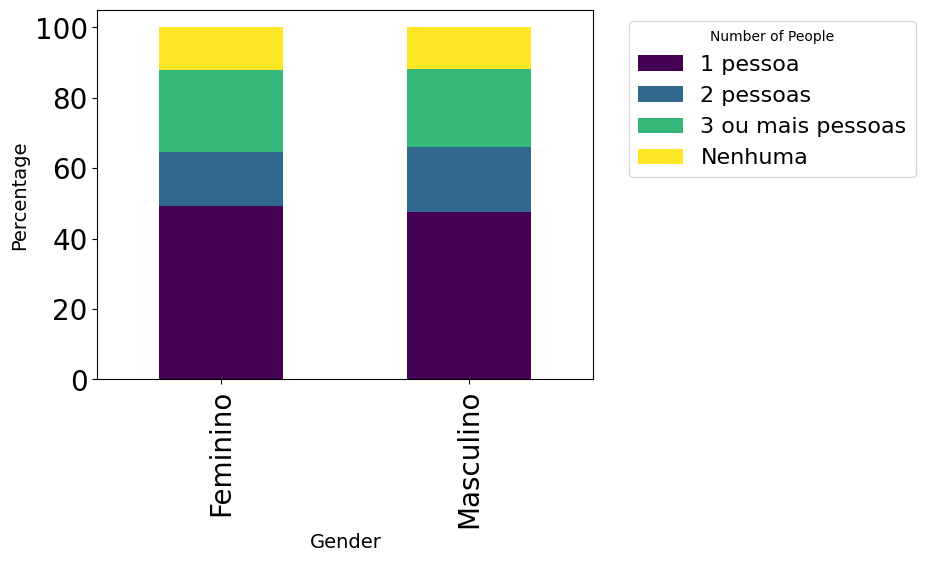

In [26]:
gender_categories = ['Feminino', 'Masculino']

filtered_df = df[df['Gender'].isin(gender_categories)]

gender_counts = filtered_df['Gender'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=gender_counts.index, y=gender_counts / gender_counts.sum() * 100, palette='viridis') 

plt.xlabel('Gender', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.title('Percentage of Gender Categories', fontsize=16)

total_responses = gender_counts.sum()
for i, v in enumerate(gender_counts):
    percentage = (v / total_responses) * 100
    plt.text(i, percentage, f'{percentage:.2f}%', ha='center', va='bottom', fontsize=12)

plt.savefig('gender_percentage.png', dpi=300, bbox_inches='tight')

plt.show()

grouped_data = filtered_df.groupby(['Gender', 'How many people accompanied you on this visit?']).size().unstack().fillna(0)

grouped_data_percentage = grouped_data.div(grouped_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
ax = grouped_data_percentage.plot(kind='bar', stacked=True, colormap='viridis', fontsize=20)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Percentage', fontsize=14)
plt.legend(title='Number of People', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

plt.savefig('accompany_percentage.png', dpi=300, bbox_inches='tight')

plt.show()


# Is this your first time visiting the Museum of Tomorrow?

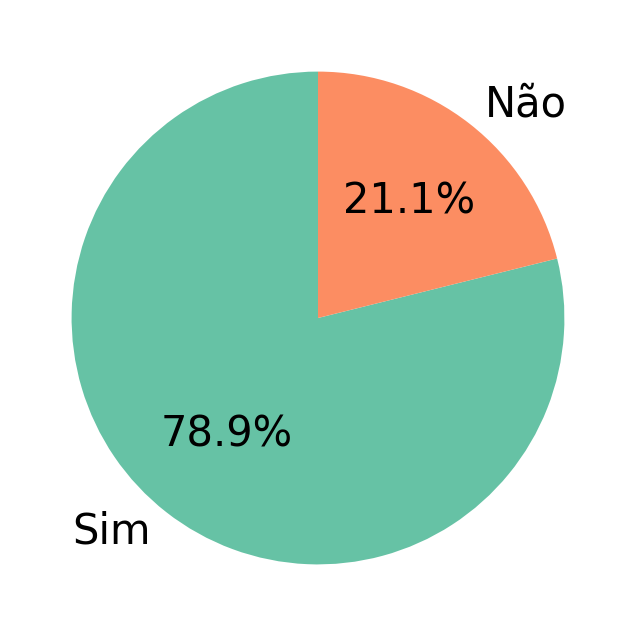

In [28]:
counts = df['Is this your first time visiting the Museum of Tomorrow?'].value_counts()

labels = counts.index
sizes = counts.values

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 30})

plt.savefig('firsttime_pie.png', dpi=300, bbox_inches='tight')

plt.show()

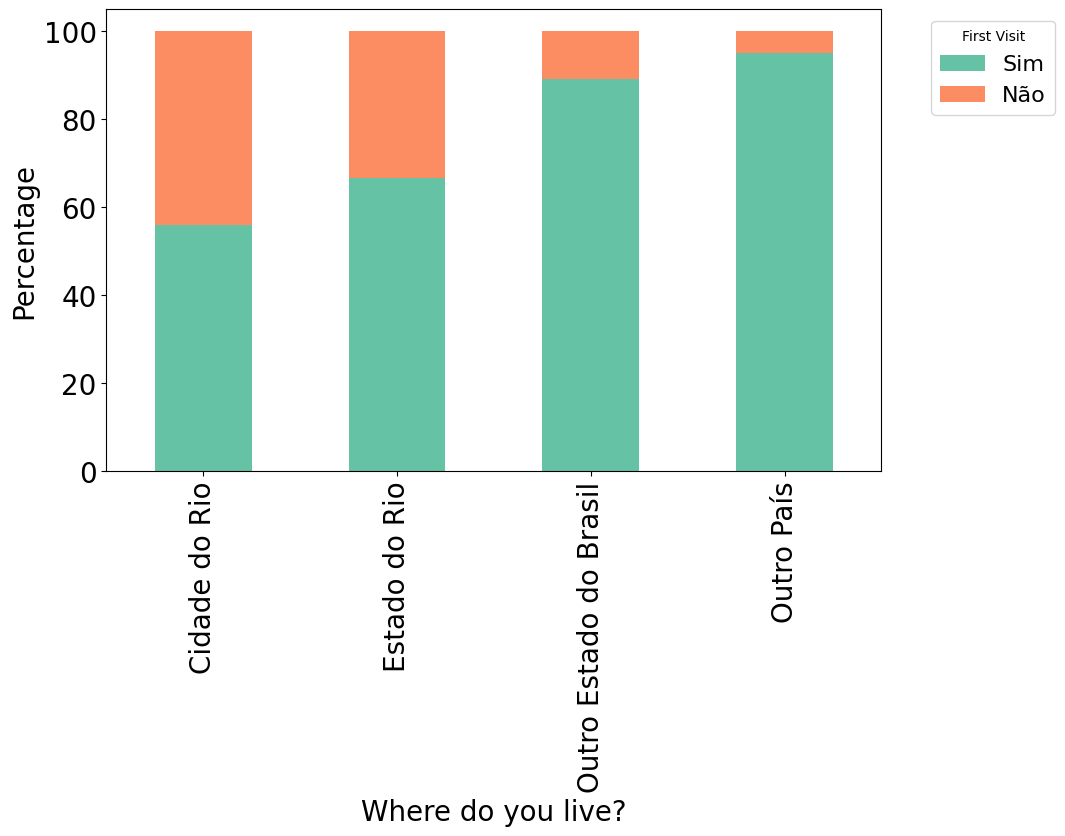

In [29]:
desired_order = ['Sim', 'Não']
df['Is this your first time visiting the Museum of Tomorrow?'] = pd.Categorical(df['Is this your first time visiting the Museum of Tomorrow?'], categories=desired_order, ordered=True)

grouped_data = df.groupby(['Where do you live?', 'Is this your first time visiting the Museum of Tomorrow?']).size().unstack().fillna(0)

grouped_data_percentage = grouped_data.div(grouped_data.sum(axis=1), axis=0) * 100

ax = grouped_data_percentage[desired_order].plot(kind='bar', stacked=True, figsize=(10, 6), fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel('Percentage', fontsize=20)
plt.legend(title='First Visit', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

plt.savefig('firsttime_percentage.png', dpi=300, bbox_inches='tight')

plt.show()

# Would you like to visit the museum again in the future?

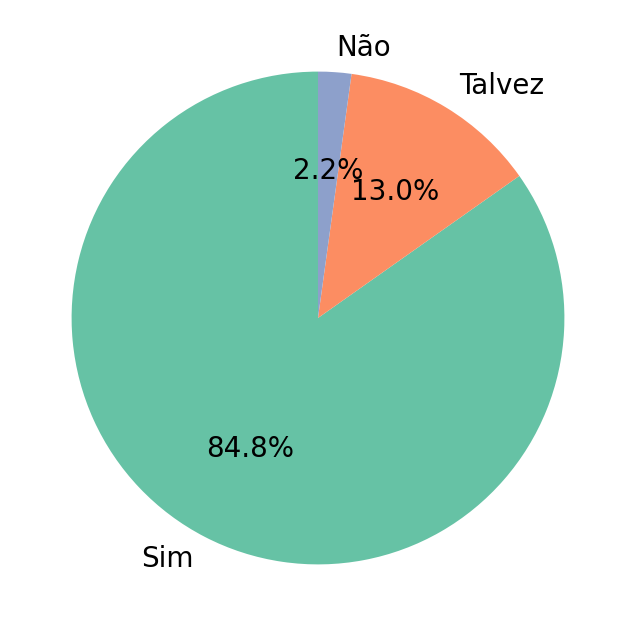

In [31]:
counts = df['Would you like to visit the museum again in the future?'].value_counts()

labels = counts.index
sizes = counts.values

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})

plt.savefig('visitagain_pie.png', dpi=300, bbox_inches='tight')

plt.show()

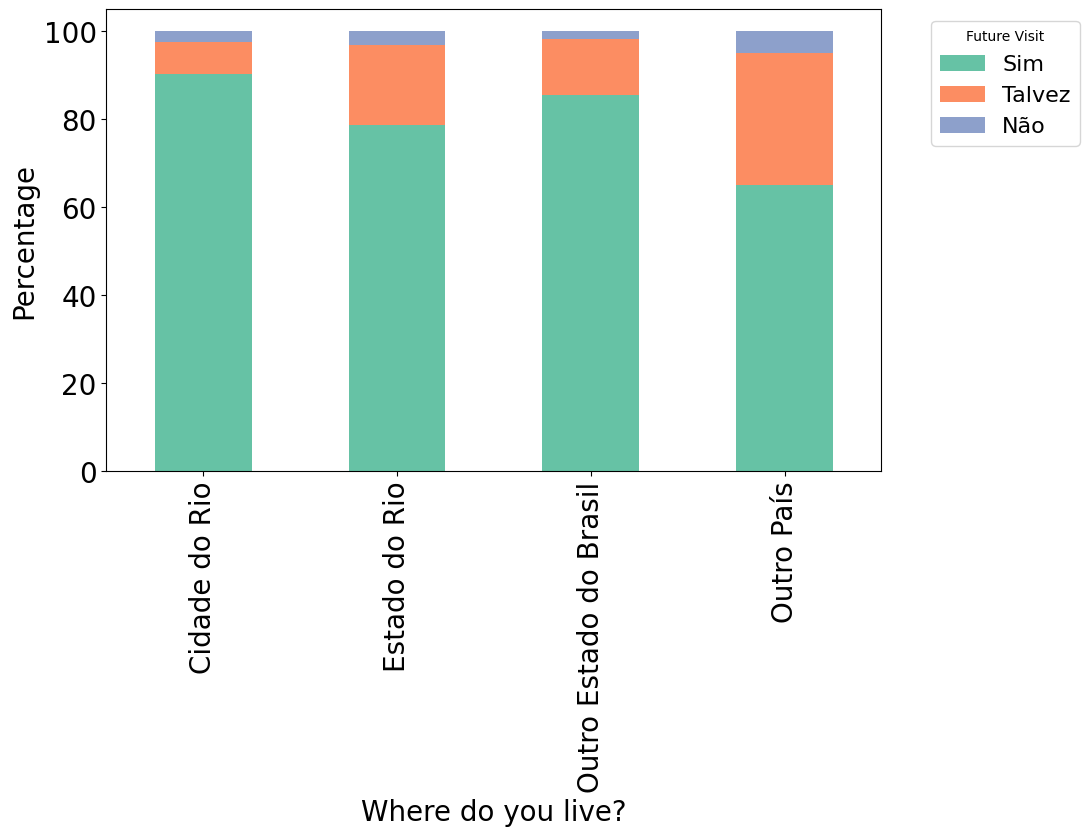

In [33]:

# Specify the desired order of the 'Would you like to visit the museum again in the future?' categories
desired_order = ['Sim', 'Talvez', 'Não']

# Convert the 'Would you like to visit the museum again in the future?' column to a Categorical column with the desired order
df['Would you like to visit the museum again in the future?'] = pd.Categorical(df['Would you like to visit the museum again in the future?'], categories=desired_order, ordered=True)

# Group the data by 'Where do you live?' and 'Would you like to visit the museum again in the future?' and count the responses
grouped_data = df.groupby(['Where do you live?', 'Would you like to visit the museum again in the future?']).size().unstack().fillna(0)

# Calculate the percentage of each category within each 'Where do you live?' group
grouped_data_percentage = grouped_data.div(grouped_data.sum(axis=1), axis=0) * 100

# Create a stacked bar plot with the desired order on the x-axis
ax = grouped_data_percentage[desired_order].plot(kind='bar', stacked=True, figsize=(10, 6), fontsize=20)

# Customize the plot (add labels, title, etc.)
plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel('Percentage', fontsize=20)
# plt.title('Demographics of Visitors by Where They Live and Future Visit Intent', fontsize=16)
plt.legend(title='Future Visit', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

plt.savefig('visitagain_percentage.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

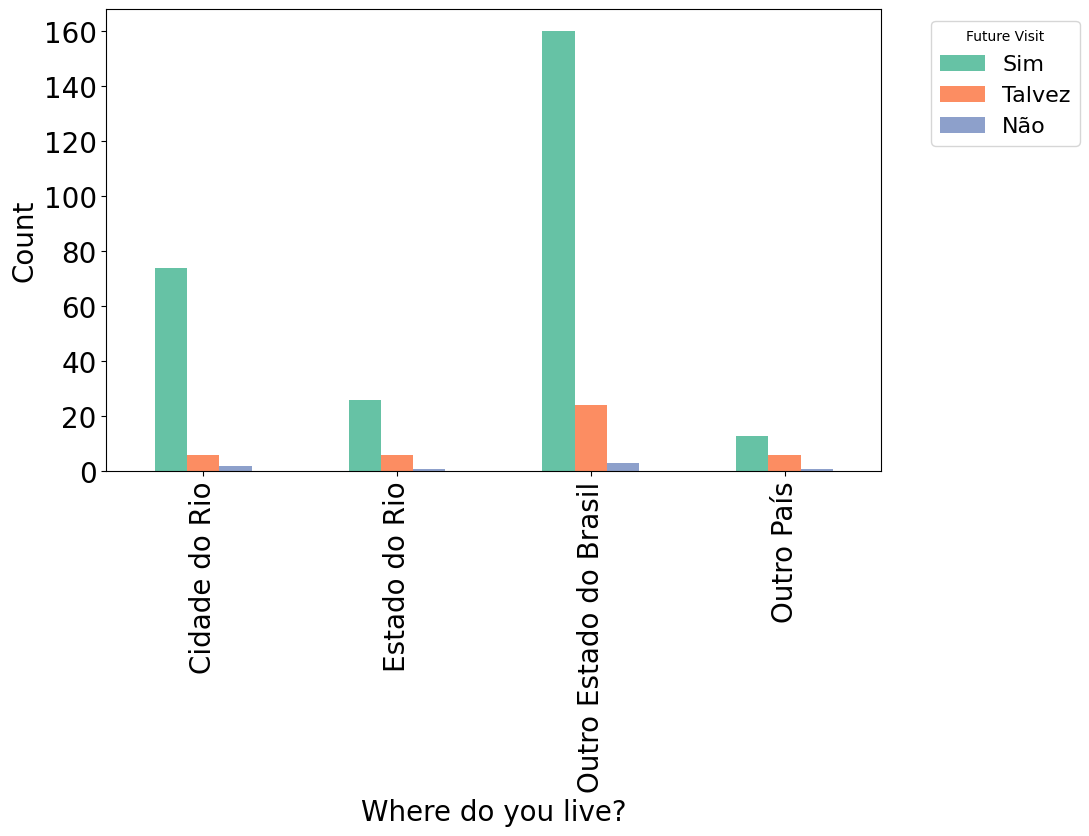

In [34]:
desired_order = ['Sim', 'Talvez', 'Não']

df['Would you like to visit the museum again in the future?'] = pd.Categorical(
    df['Would you like to visit the museum again in the future?'],
    categories=desired_order,
    ordered=True
)

grouped_data = df.groupby(['Where do you live?', 'Would you like to visit the museum again in the future?']).size().unstack().fillna(0)

ax = grouped_data.plot(kind='bar', stacked=False, figsize=(10, 6), fontsize=20)

plt.xlabel('Where do you live?', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.legend(title='Future Visit', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

plt.savefig('visitagain_counts.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [35]:
unique_answers = df['Gender'].unique()

# Print the unique answers
for answer in unique_answers:
    print(answer)

Feminino
Masculino
Não-binárie
Não sei / Prefiro não responder


# Do you have any disabilities?

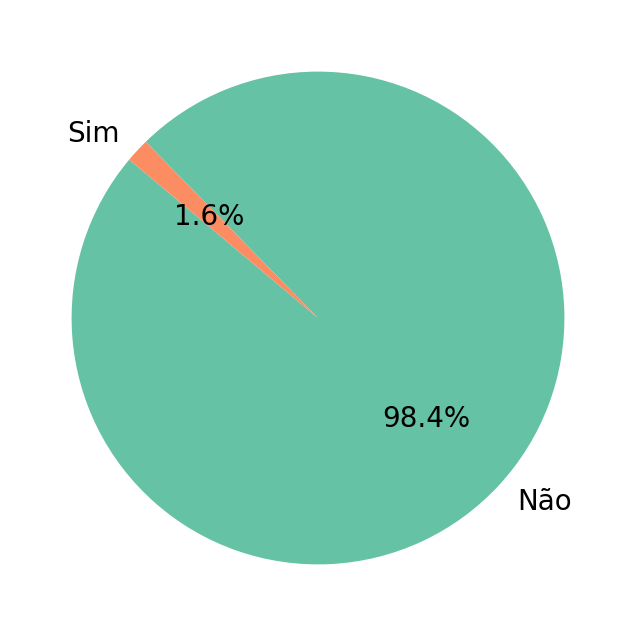

In [36]:
desired_order = ['Sim', 'Não']

# Convert the 'Do you have any disabilities?' column to a Categorical column with the desired order
df['Do you have any disabilities?'] = pd.Categorical(df['Do you have any disabilities?'], categories=desired_order, ordered=True)

counts = df['Do you have any disabilities?'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 20})
# plt.title('Disabilities - Sim vs. Não')

plt.savefig('disabled.png', dpi=300, bbox_inches='tight')

plt.show()

In [37]:
sim_answers = df[df['Do you have any disabilities?'] == 'Sim']

# Print the answers where 'Do you have any disabilities?' is 'Sim'
print(sim_answers['What disability do you have?'])

1             Outra
272          Visual
238        Auditiva
150          Visual
164    Psicossocial
Name: What disability do you have?, dtype: object
